Überschrift und erklärung

In [1]:
# -------------------------------
# Import necessary libraries
# -------------------------------
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation
import tensorflow as tf  # Import TensorFlow for building neural network models
import seaborn as sns  # Import Seaborn for statistical plotting
import matplotlib.pyplot as plt  # Import Matplotlib for creating plots
from sklearn.model_selection import train_test_split  # Import train_test_split for splitting datasets
from sklearn.metrics import mean_squared_error, r2_score  # Import metrics for evaluating models
from sklearn.linear_model import LinearRegression, HuberRegressor, ElasticNet  # Import linear regression models
from sklearn.decomposition import PCA  # Import PCA for dimensionality reduction
from sklearn.cross_decomposition import PLSRegression  # Import PLSRegression for partial least squares regression
from sklearn.preprocessing import SplineTransformer  # Import SplineTransformer for spline feature transformation
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor  # Import ensemble regression models

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')  # Set the plotting style to Seaborn whitegrid

**Part 1: Data Generation**

We simulate a panel of **10 stocks** over **24 months**, each with **5 firm-level characteristics** and **3 macroeconomic factors**. 


In [3]:
# -------------------------------
# Part 1: Data Generation
# -------------------------------
n_stocks = 10  # Define the number of stocks
n_months = 24  # Define the number of months (time periods)
n_characteristics = 5  # Define the number of stock-specific characteristics
n_macro_factors = 3  # Define the number of macroeconomic factors

np.random.seed(42)  # Set the random seed for reproducibility
stock_characteristics = np.random.rand(n_stocks, n_months, n_characteristics)  # Generate random stock characteristic data
macro_factors = np.random.rand(n_months, n_macro_factors)  # Generate random macroeconomic factor data

zi_t = np.zeros((n_stocks, n_months, n_characteristics * n_macro_factors))

for t in range(n_months):
    for i in range(n_stocks):
        zi_t[i,t] = np.outer(macro_factors[t], stock_characteristics[i,t]).flatten()

theta = np.random.rand(n_characteristics * n_macro_factors)
ri_t_plus_1 = np.zeros((n_stocks, n_months))

for t in range(n_months):
    for i in range(n_stocks):
        ri_t_plus_1[i,t] = zi_t[i,t].dot(theta) + np.random.normal(0, 0.05)

zi_t_flattened = zi_t.reshape(n_stocks * n_months, -1)

ri_t_flattened = ri_t_plus_1.flatten()

zi_t_df = pd.DataFrame(zi_t_flattened, columns=[f"z_{k + 1}" for k in range(zi_t_flattened.shape[1])])
zi_t_df["Stock_ID"] = np.repeat(range(1, n_stocks + 1), n_months)
zi_t_df["Month"] = np.tile(range(1, n_months + 1), n_stocks)

ri_t_df = pd.DataFrame({
    "Stock_ID" : np.repeat(range(1, n_stocks + 1), n_months),
    "Month" : np.tile(range(1, n_months + 1), n_stocks),
    "Excess_Return" : ri_t_flattened
})

combined_data = pd.concat([zi_t_df,ri_t_df["Excess_Return"]], axis=1)

In [4]:
combined_data.head(2)
print(theta)

[0.77985099 0.03961883 0.48050695 0.10493018 0.24204502 0.98666259
 0.14249554 0.49888815 0.61815573 0.70246497 0.55964868 0.00977085
 0.32646131 0.51771164 0.0878665 ]


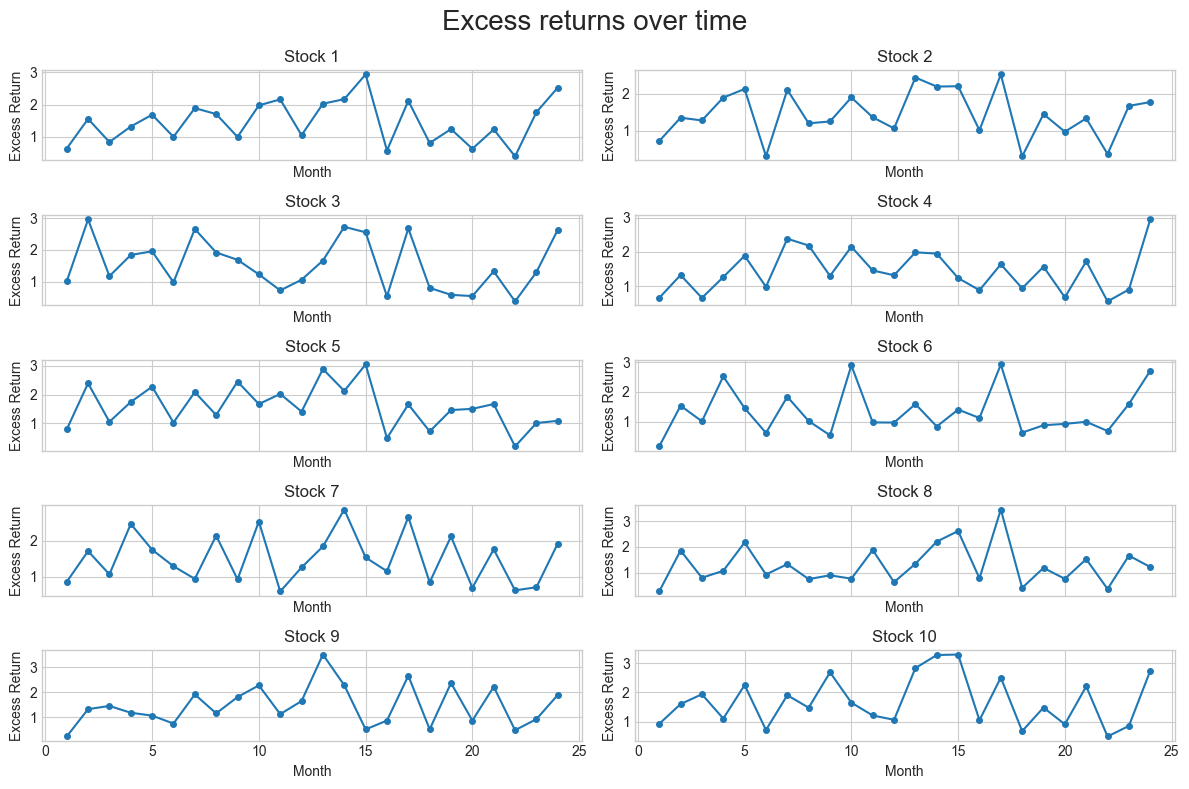

In [5]:
# create a 5x2 grid of subplots for the 10 stocks
fig, axes = plt.subplots(5, 2, sharex=True, sharey=False,figsize=(12, 8))
axes = axes.flatten()

for i, stock_id in enumerate(sorted(combined_data["Stock_ID"].unique())):
    df_stock = combined_data[combined_data["Stock_ID"] == stock_id].sort_values("Month")
    axes[i].plot(df_stock["Month"], df_stock["Excess_Return"], marker='o', linestyle='-', markersize = 4)
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")

fig.suptitle("Excess returns over time", fontsize=20)
plt.tight_layout()
plt.show()

In [6]:
# -------------------------------
# Part 2: Train–Validation–Test Split
# -------------------------------
X = combined_data[[col for col in combined_data.columns if col.startswith('z_')]]
y = combined_data["Excess_Return"]

X_train_val , X_test , y_train_val , y_test = train_test_split(zi_t_flattened, ri_t_flattened, test_size=0.3, random_state=42)
X_train , X_val , y_train , y_val = train_test_split(X_train_val, y_train_val, test_size=0.2857, random_state=42)

In [7]:
# -------------------------------
# Part 3: Model Training Section
# -------------------------------

In [8]:
# --- OLS Regression ---
ols_model = LinearRegression()
ols_model.fit(X_train,y_train)

y_pred_ols = ols_model.predict(X_test)

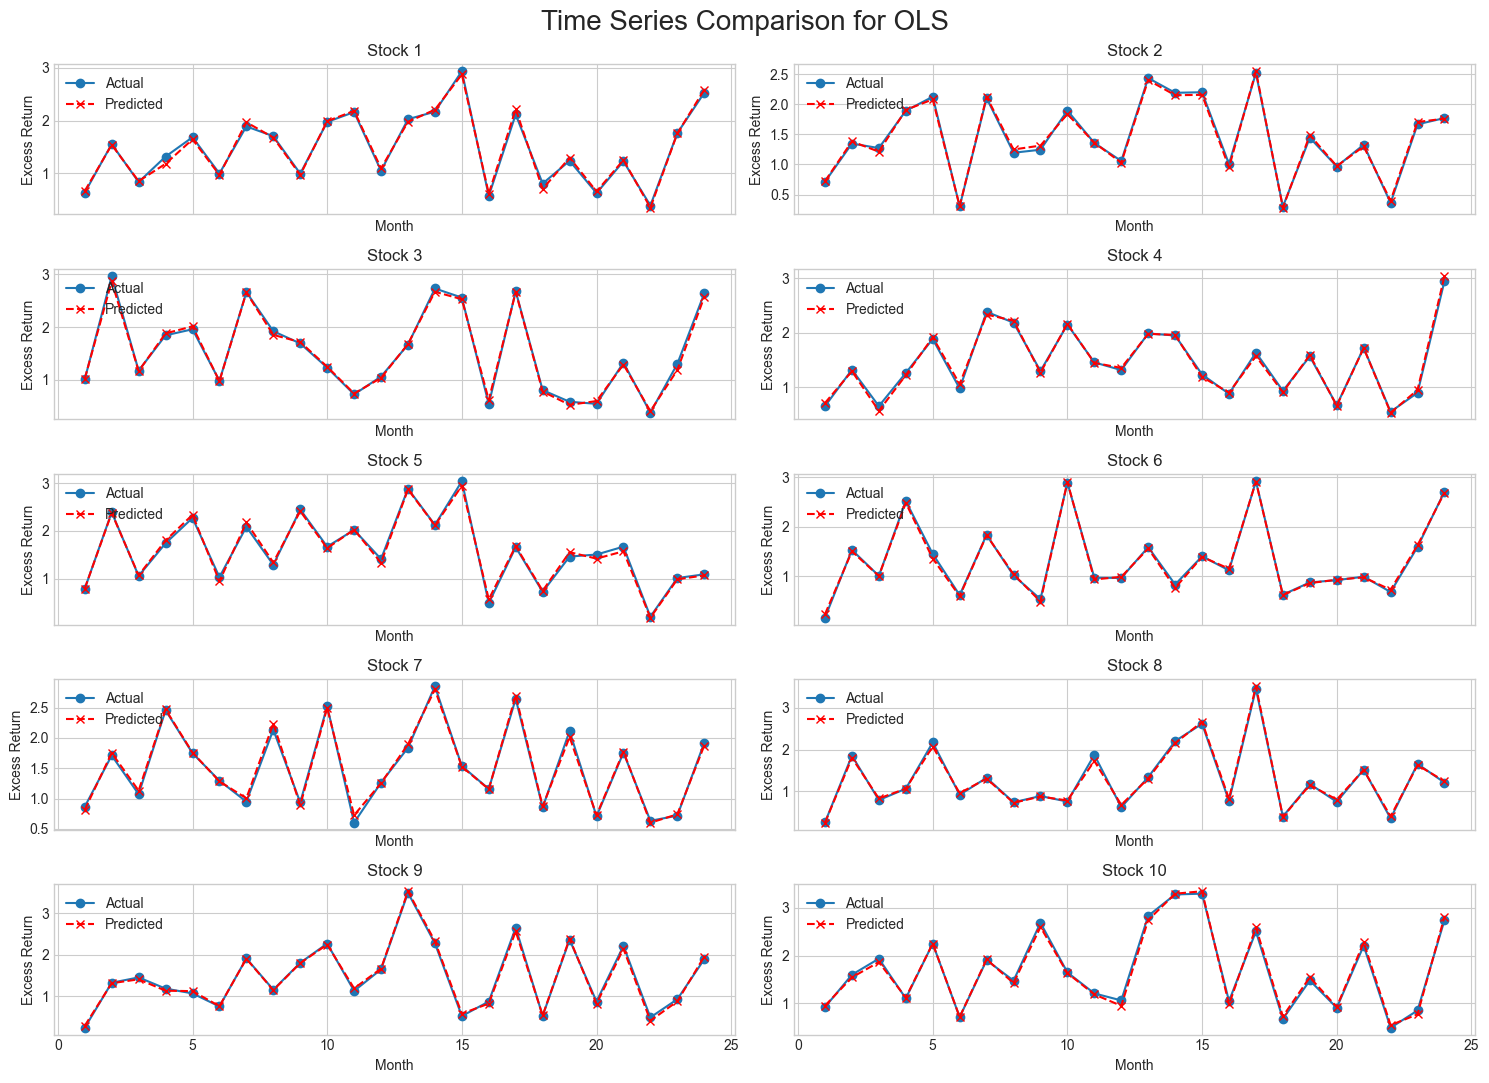

In [9]:
# --- OLS Regression for all observations ---
X_all = X.to_numpy()
y_pred_ols_all = ols_model.predict(X_all)

fig, axes = plt.subplots(5, 2, sharex=True, figsize=(15, 11))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for OLS", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx = df_s.index
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_ols_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [10]:
# --- Weighted Linear Regression ---
class WeightedLinearRegression:
    """
    Implements weighted ordinary least squares regression using the normal equations.
    Observations are weighted by the provided sample weights.
    """
    def __init__(self):
        # theta will hold the fitted coefficient vector (P×1)
        self.theta = None

    def fit(self, X, y, weights):
        """
        Fit the weighted least squares model.
        
        Parameters:
        X       : ndarray of shape (N, P)
                  Design matrix of predictors.
        y       : ndarray of shape (N,)
                  Target vector of responses.
        weights : ndarray of shape (N,)
                  Sample weights for each observation.
        """
        # Construct the diagonal weight matrix W
        W = np.diag(weights)
        # Compute θ = (Xᵀ W X)^(-1) Xᵀ W y
        self.theta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)

    def predict(self, X):
        """
        Predict responses for new data using the fitted coefficients.
        
        Parameters:
        X : ndarray of shape (M, P)
            New design matrix.
        
        Returns:
        y_pred : ndarray of shape (M,)
                 Predicted responses.
        """
        return X @ self.theta


In [11]:
# create DataFrame with features, target, and weights
data = pd.DataFrame(zi_t_flattened, columns=[f"z_{k + 1}" for k in range(zi_t_flattened.shape[1])])
data["Excess_Return"] = ri_t_flattened
data["weights"] = np.random.rand(n_stocks * n_months)

# split into train and test (preserving weights)
train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

# extract predictor matrix, target vector, and sample weights
X_train = train_data.drop(columns=["Excess_Return", "weights"]).values
y_train = train_data["Excess_Return"].values
w_train = train_data["weights"].values

X_test  = test_data.drop(columns=["Excess_Return", "weights"]).values
y_test  = test_data["Excess_Return"].values
w_test  = test_data["weights"].values

# fit weighted least squares and predict
wls = WeightedLinearRegression()
wls.fit(X_train, y_train, w_train)
y_pred_wls = wls.predict(X_test)

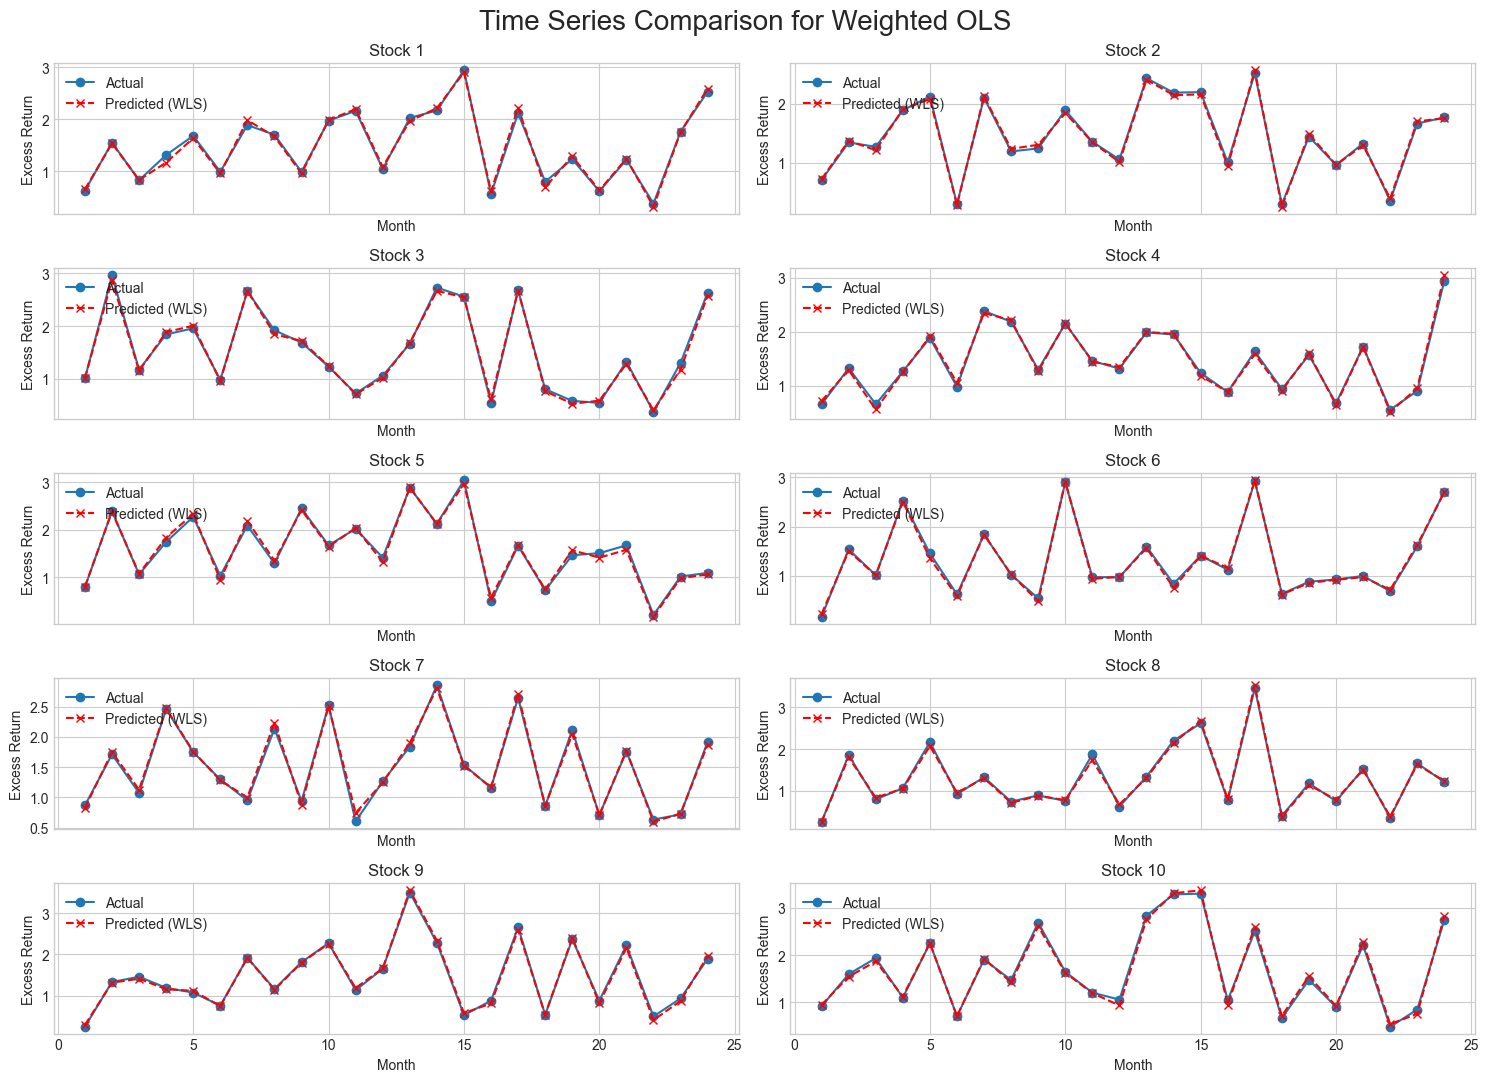

In [12]:
# compute WLS predictions for all observations
y_pred_wls_all = wls.predict(X_all)

# plot actual vs. weighted‐OLS predicted per stock using y_pred_wls_all
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(15, 11))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Weighted OLS", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index  # get original indices for this stock
    
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_wls_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (WLS)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [13]:
# --- Huber Regressor ---
huber_model = HuberRegressor()
huber_model.fit(X_train, y_train)

y_pred_huber = huber_model.predict(X_test)

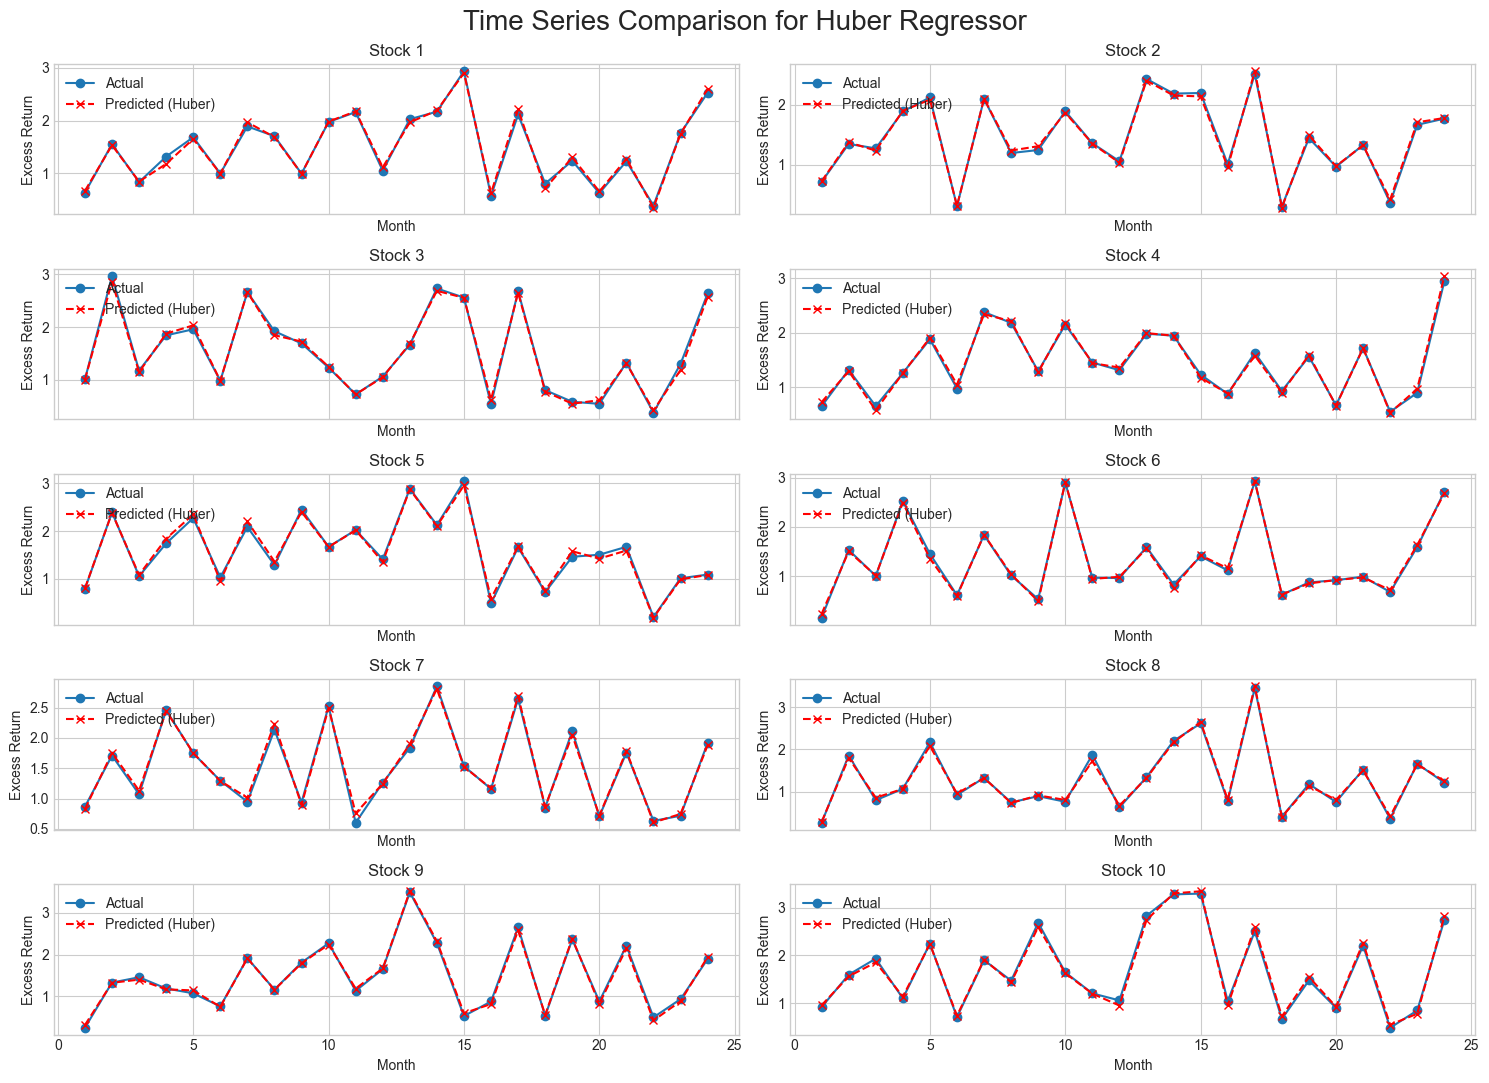

In [14]:
# compute Huber predictions for all observations
y_pred_huber_all = huber_model.predict(X_all)

# plot actual vs. Huber predicted per stock using y_pred_huber_all
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(15, 11))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Huber Regressor", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index  # original indices for this stock
    
    # actual returns
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    # Huber predictions
    axes[i].plot(
        df_s['Month'], y_pred_huber_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (Huber)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [15]:
# --- ElasticNet Model Tuning ---
best_enet = {"mse":np.inf}
for alpha in [0.01,0.1,1,10]:
    for l1_ratio in [0.1,0.5,0.9]:
        en = ElasticNet(alpha=alpha,l1_ratio=l1_ratio,max_iter=1000,random_state=42)
        en.fit(X_train,y_train)
        mse = mean_squared_error(y_val,en.predict(X_val))
        if mse < best_enet['mse']:
            best_enet.update({"mse":mse,"alpha":alpha,"l1_ratio":l1_ratio})
            
enet = ElasticNet(alpha=best_enet['alpha'],l1_ratio=best_enet['l1_ratio'],max_iter=5000,random_state=42)
enet.fit(np.vstack([X_train,X_val]),np.concatenate([y_train,y_val]))

y_pred_enet = enet.predict(X_test)

In [16]:
# --- ElasticNet Model Tuning ---
# We perform a manual grid search over regularization strength (alpha) and L1/L2 mixing (l1_ratio)
# to minimize validation MSE.
best_enet = {"mse": np.inf}

for alpha in [0.01, 0.1, 1, 10]:
    for l1_ratio in [0.1, 0.5, 0.9]:
        # alpha controls overall regularization strength
        # l1_ratio determines the mix between L1 (lasso) and L2 (ridge)
        en = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=1000,      
            random_state=42
        )
        en.fit(X_train, y_train)  # fit on training set
        mse = mean_squared_error(y_val, en.predict(X_val))  # evaluate on validation set
        if mse < best_enet["mse"]:
            best_enet.update({
                "mse": mse,
                "alpha": alpha,
                "l1_ratio": l1_ratio
            })

enet = ElasticNet(
    alpha=best_enet["alpha"],
    l1_ratio=best_enet["l1_ratio"],
    max_iter=1000,
    random_state=42
)
enet.fit(
    np.vstack([X_train, X_val]),
    np.concatenate([y_train, y_val])
)

# Generate predictions on the test set
y_pred_enet = enet.predict(X_test)

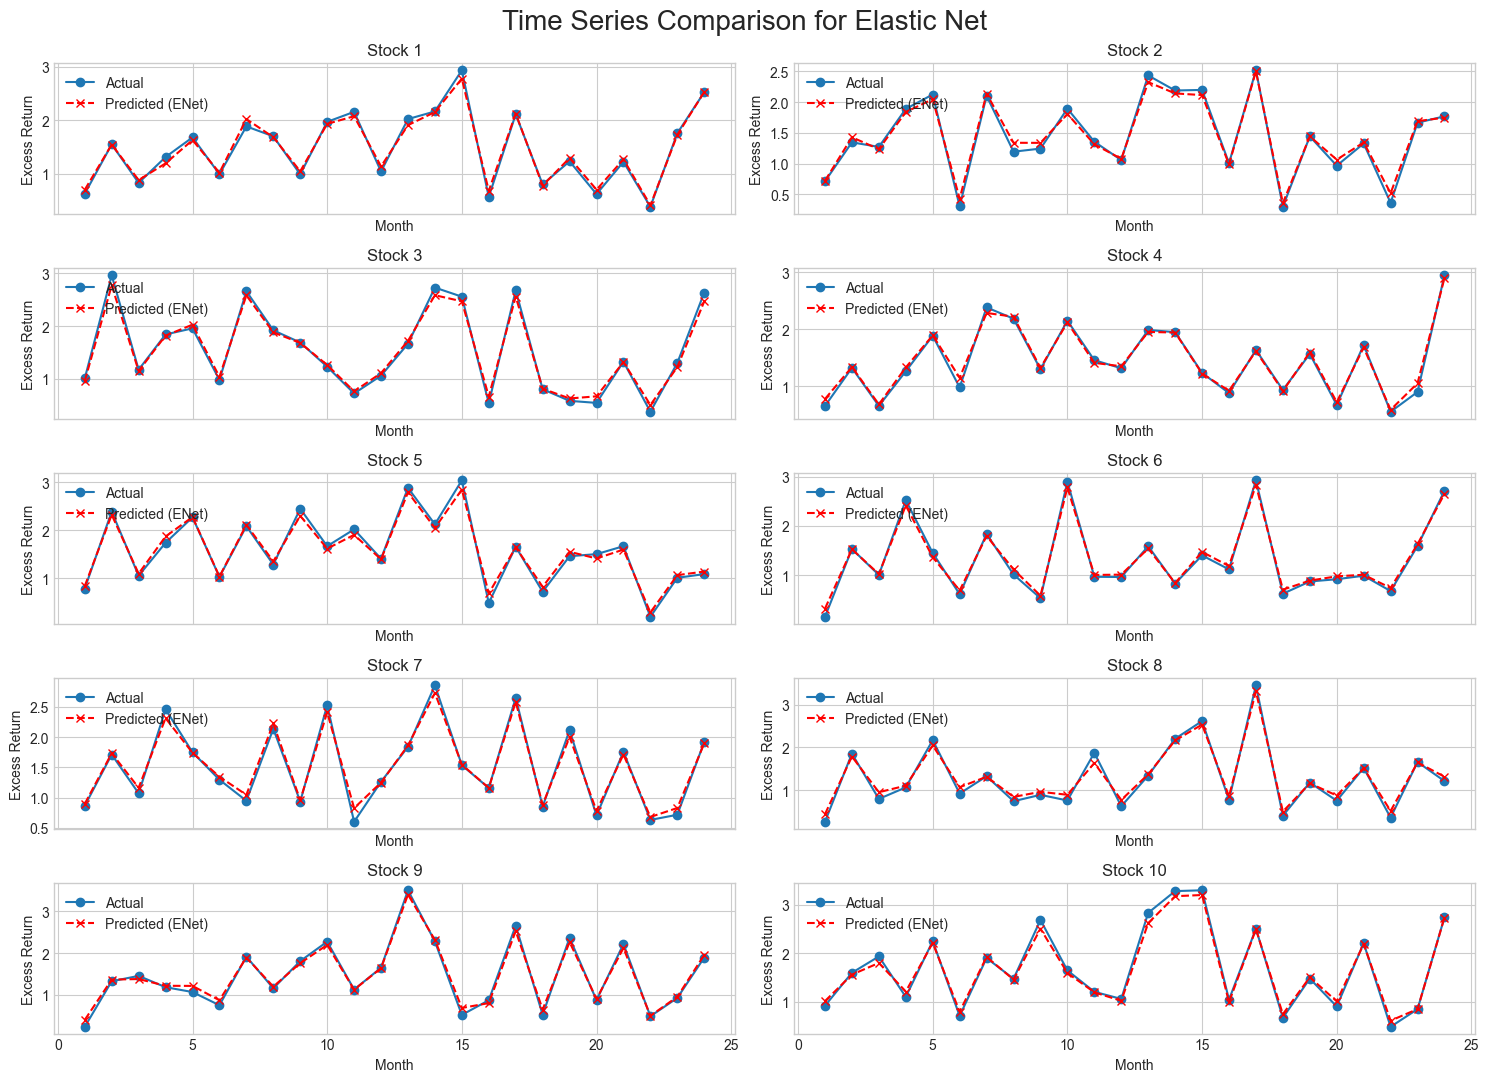

In [17]:
# compute Elastic Net predictions for all observations
y_pred_enet_all = enet.predict(X_all)

# plot actual vs. Elastic Net predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(15, 11))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Elastic Net", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index  # original indices for this stock
    
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_enet_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (ENet)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
# --- Principal Component Regression (PCR) ---

# 1) Tune number of components (k) using validation set
best_pcr = {"mse": np.inf, "k": None}

for k in range(1, min(X_train.shape[1], 20) + 1):
    # a) Fit PCA with k components on training data
    pca_tune = PCA(n_components=k).fit(X_train)
    
    # b) Transform both training and validation sets
    X_train_pca = pca_tune.transform(X_train)
    X_val_pca   = pca_tune.transform(X_val)
    
    # c) Fit linear regression on reduced training data
    lr_tune = LinearRegression().fit(X_train_pca, y_train)
    
    # d) Predict on validation set and compute MSE
    y_val_pred = lr_tune.predict(X_val_pca)
    mse_val    = mean_squared_error(y_val, y_val_pred)
    
    # e) Update best number of components if MSE improved
    if mse_val < best_pcr["mse"]:
        best_pcr.update({"mse": mse_val, "k": k})

# 2) Re-fit PCA on combined training + validation set with best k
pca_final = PCA(n_components=best_pcr["k"])
X_trval   = np.vstack([X_train, X_val])
X_trval_pca = pca_final.fit_transform(X_trval)

# 3) Fit final regression on reduced train+val data
lr_pcr = LinearRegression().fit(X_trval_pca, np.concatenate([y_train, y_val]))

# 4) Transform test set and make PCR predictions
X_test_pca   = pca_final.transform(X_test)
y_pred_pcr   = lr_pcr.predict(X_test_pca)

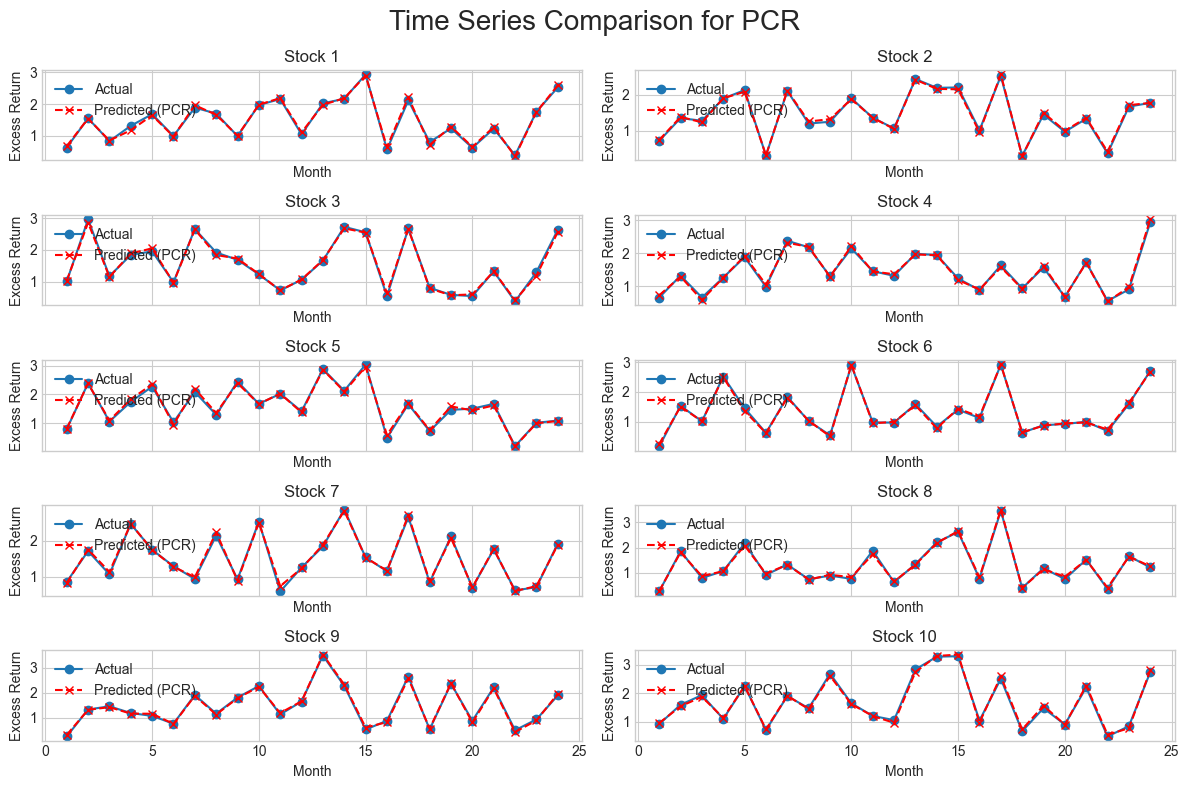

In [19]:
# --- PCR plotting with your fitted objects ---
X_all_pca     = pca_final.transform(X_all)       # use pca_final
y_pred_pcr_all = lr_pcr.predict(X_all_pca)       # use lr_pcr

fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for PCR", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(df_s['Month'], df_s['Excess_Return'],
                 marker='o', linestyle='-', label='Actual')
    axes[i].plot(df_s['Month'], y_pred_pcr_all[idx],
                 marker='x', linestyle='--', color='red', label='Predicted (PCR)')
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [20]:
# --- Partial Least Squares Regression (PLS) ---

# 1) Tune number of PLS components using the validation set
best_pls = {"mse": np.inf, "n_components": None}

for n_comp in range(1, min(X_train.shape[1], 20) + 1):
    # a) Initialize and fit PLS with n_comp components
    pls_tune = PLSRegression(n_components=n_comp).fit(X_train, y_train)
    
    # b) Predict on validation set
    y_val_pred = pls_tune.predict(X_val)
    
    # c) Compute validation MSE
    mse_val = mean_squared_error(y_val, y_val_pred)
    
    # d) Update best configuration if current MSE is lower
    if mse_val < best_pls["mse"]:
        best_pls.update({"mse": mse_val, "n_components": n_comp})

# 2) Refit PLS on combined train+val data with the best number of components
pls_final = PLSRegression(n_components=best_pls["n_components"])
X_trval = np.vstack([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])
pls_final.fit(X_trval, y_trval)

# 3) Generate test-set predictions and flatten to 1D array
y_pred_pls = pls_final.predict(X_test).flatten()

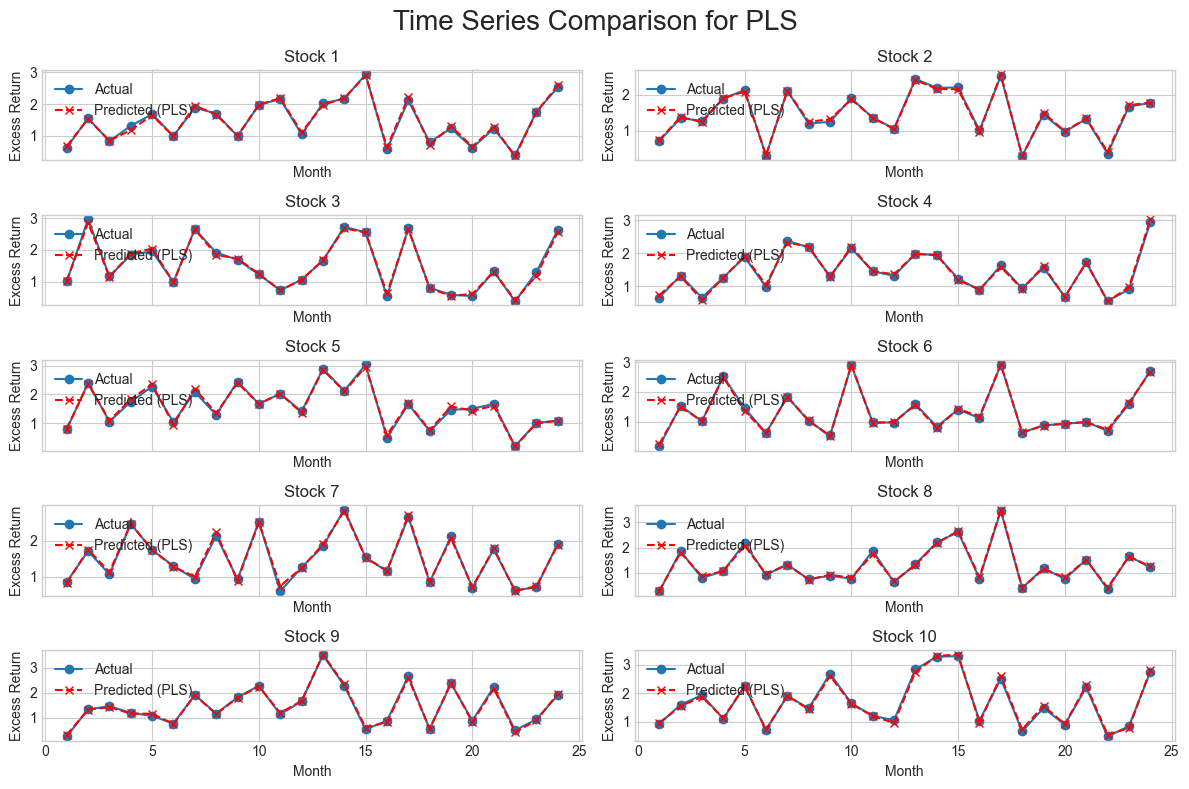

In [21]:
# compute PLS predictions for all observations
y_pred_pls_all = pls_final.predict(X_all).flatten()

# plot actual vs. PLS predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for PLS", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_pls_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (PLS)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [22]:
# --- Generalized Linear Model (GLM) with Spline Expansion + Elastic Net Regularization ---

# 1) Spline-transform the original features
spline_degree = 2
n_knots = 5
spline = SplineTransformer(
    degree=spline_degree,
    n_knots=n_knots,
    knots="uniform",
    include_bias=False
)
X_train_spline = spline.fit_transform(X_train)
X_val_spline   = spline.transform(X_val)
X_test_spline  = spline.transform(X_test)

# 2) Hyperparameter tuning on the validation set
best_glm = {"mse": np.inf, "alpha": None, "l1_ratio": None}
alpha_grid = np.logspace(-3, 1, 10)
l1_ratios  = [0.1, 0.5, 0.9]

for alpha in alpha_grid:
    for l1 in l1_ratios:
        # initialize ElasticNet with current hyperparameters
        glm_candidate = ElasticNet(
            alpha=alpha,
            l1_ratio=l1,
            max_iter=10000,
            random_state=42
        )
        # fit on spline-expanded training data
        glm_candidate.fit(X_train_spline, y_train)
        # predict on spline-expanded validation data
        y_val_pred = glm_candidate.predict(X_val_spline)
        val_mse    = mean_squared_error(y_val, y_val_pred)
        
        # update best hyperparameters if MSE improves
        if val_mse < best_glm["mse"]:
            best_glm.update({"mse": val_mse, "alpha": alpha, "l1_ratio": l1})

# 3) Refit the final model on combined train+val data
glm_final = ElasticNet(
    alpha=best_glm["alpha"],
    l1_ratio=best_glm["l1_ratio"],
    max_iter=10000,
    random_state=42
)
X_combined_spline = np.vstack([X_train_spline, X_val_spline])
y_combined        = np.concatenate([y_train, y_val])
glm_final.fit(X_combined_spline, y_combined)

# 4) Generate GLM predictions on the test set
y_pred_glm = glm_final.predict(X_test_spline)


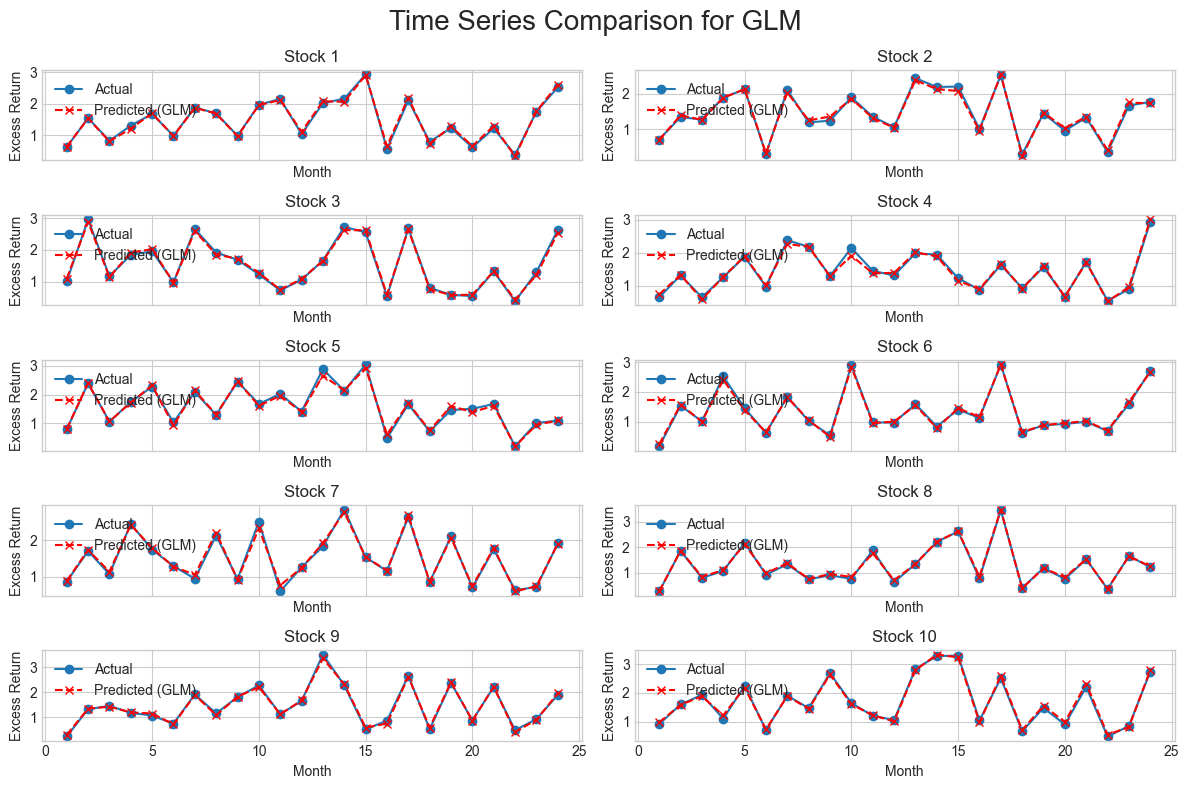

In [23]:
# compute GLM predictions for all observations using the final fitted model
X_all_spline  = spline.transform(X_all)
glm_pred_all  = glm_final.predict(X_all_spline)

# plot actual vs. GLM predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for GLM", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], glm_pred_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (GLM)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [24]:
# --- Gradient Boosting Regressor (GBR) ---

# 1) Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

# 2) Grid search on validation set to find best params
best_gbr = {"rmse": np.inf, "params": None}

for n_trees in param_grid["n_estimators"]:
    for lr in param_grid["learning_rate"]:
        for depth in param_grid["max_depth"]:
            # initialize model with current combination
            candidate = GradientBoostingRegressor(
                n_estimators=n_trees,
                learning_rate=lr,
                max_depth=depth,
                random_state=42
            )
            # fit on training data
            candidate.fit(X_train, y_train)
            # predict and compute RMSE on validation set
            val_preds = candidate.predict(X_val)
            val_rmse  = np.sqrt(mean_squared_error(y_val, val_preds))
            # update best if improved
            if val_rmse < best_gbr["rmse"]:
                best_gbr["rmse"]   = val_rmse
                best_gbr["params"] = {
                    "n_estimators": n_trees,
                    "learning_rate": lr,
                    "max_depth": depth
                }


# 3) Retrain final model on combined train+validation set
X_trval = np.vstack([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])

gbr_final = GradientBoostingRegressor(
    **best_gbr["params"],
    random_state=42
)
gbr_final.fit(X_trval, y_trval)

y_pred_gbr = gbr_final.predict(X_test)

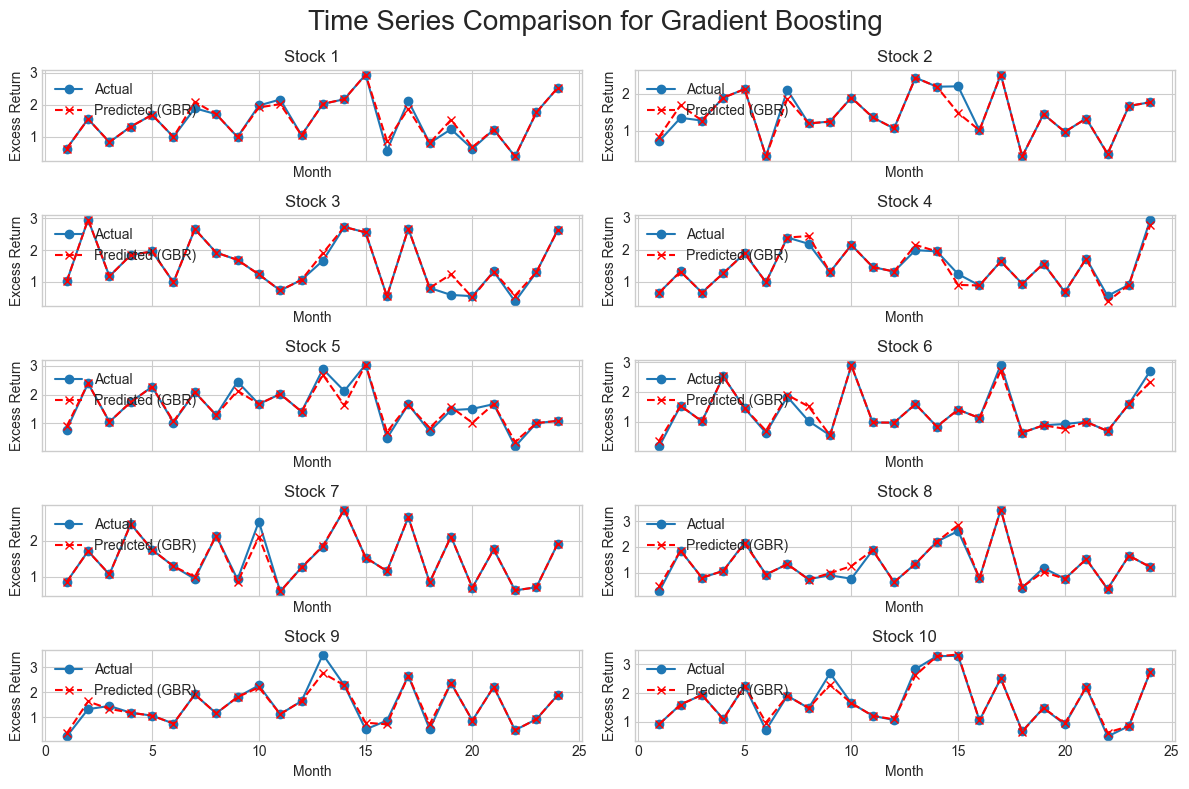

In [25]:
# compute GBR predictions for all observations
y_pred_gbr_all = gbr_final.predict(X_all)

# plot actual vs. GBR predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Gradient Boosting", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    # actual returns
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    # predicted returns
    axes[i].plot(
        df_s['Month'], y_pred_gbr_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (GBR)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [26]:
# --- Random Forest Regressor (RF) ---

# 1) Define hyperparameter grid
rf_param_grid = {
    "n_estimators":    [50, 100, 200],
    "max_depth":       [3, 5, 7],
    "min_samples_split": [2, 5, 10]
}

best_rf = {"rmse": np.inf, "params": None}

# 2) Grid search on validation set
for n_trees in rf_param_grid["n_estimators"]:
    for depth in rf_param_grid["max_depth"]:
        for min_split in rf_param_grid["min_samples_split"]:
            # initialize candidate model
            rf_candidate = RandomForestRegressor(
                n_estimators=n_trees,
                max_depth=depth,
                min_samples_split=min_split,
                random_state=42,
                n_jobs=-1
            )
            rf_candidate.fit(X_train, y_train)
            
            # predict & evaluate on validation set
            y_val_pred = rf_candidate.predict(X_val)
            val_rmse   = np.sqrt(mean_squared_error(y_val, y_val_pred))
            
            # keep track of best configuration
            if val_rmse < best_rf["rmse"]:
                best_rf["rmse"]   = val_rmse
                best_rf["params"] = {
                    "n_estimators": n_trees,
                    "max_depth": depth,
                    "min_samples_split": min_split
                }


# 3) Retrain final model on combined train+validation data
X_trval = np.vstack([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])

rf_final = RandomForestRegressor(
    **best_rf["params"],
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_trval, y_trval)

# 4) Generate predictions on the test set
y_pred_rf = rf_final.predict(X_test)


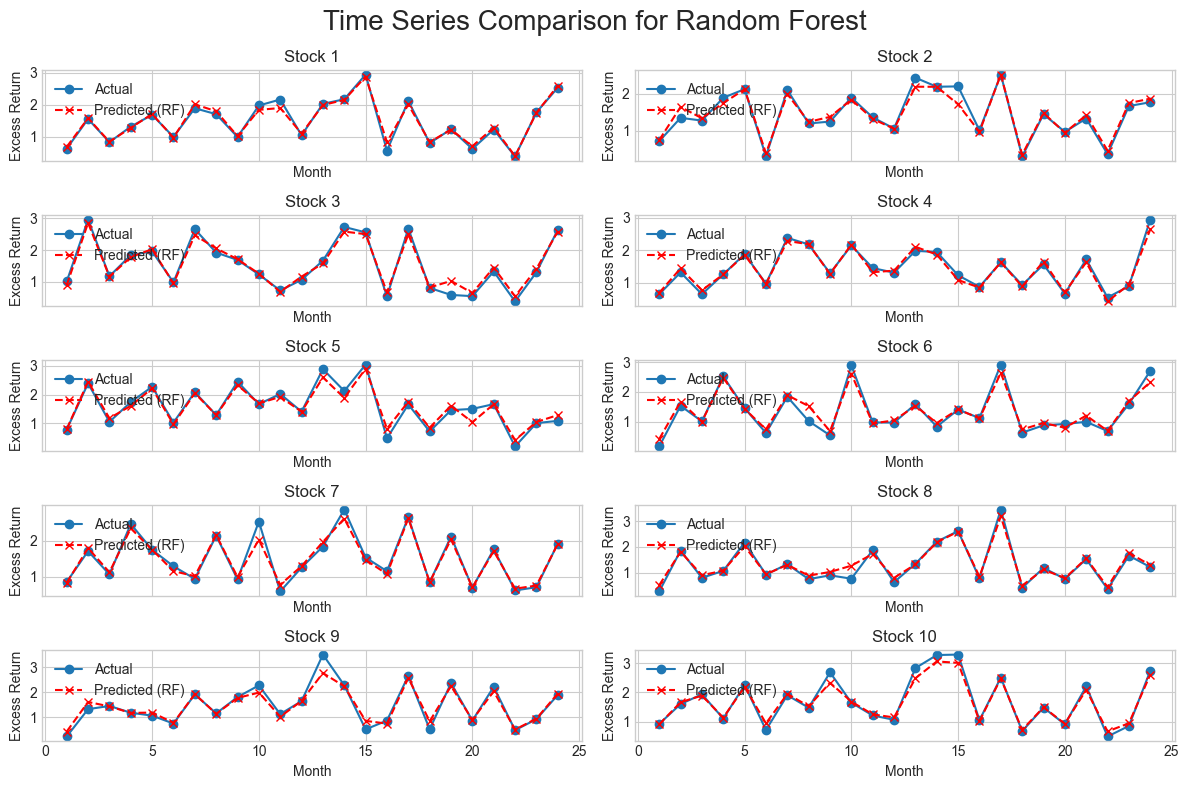

In [27]:
# compute RF predictions for all observations
y_pred_rf_all = rf_final.predict(X_all)

# plot actual vs. RF predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Random Forest", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_rf_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (RF)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [28]:
# --- Neural Network ---
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from itertools import product # Improve readability in nested loop structure

# 1) Scale features
scaler = StandardScaler().fit(X_train)
X_tr_nn = scaler.transform(X_train)
X_val_nn = scaler.transform(X_val)
X_te_nn  = scaler.transform(X_test)

# 2) Model factory
def create_model(learning_rate=0.01, layer1_units=32, layer2_units=16, layer3_units=8):
    model = keras.Sequential([
        keras.Input(shape=(X_tr_nn.shape[1],)),
        keras.layers.Dense(layer1_units, activation='relu'),
        keras.layers.Dense(layer2_units, activation='relu'),
        keras.layers.Dense(layer3_units, activation='relu'),
        keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

# 3) Hyperparameter grid
learning_rates = [0.001, 0.01, 0.1]
layer1_units   = [32, 64]
layer2_units   = [16, 32]
layer3_units   = [8, 16]

early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

best_nn = {"val_loss": float('inf'), "params": None, "model": None}

# 4) Grid search over all combinations
for lr, n1, n2, n3 in product(learning_rates, layer1_units, layer2_units, layer3_units):
    model = create_model(learning_rate=lr,
                         layer1_units=n1,
                         layer2_units=n2,
                         layer3_units=n3)
    history = model.fit(
        X_tr_nn, y_train,
        validation_data=(X_val_nn, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    val_loss = min(history.history['val_loss'])
    if val_loss < best_nn['val_loss']:
        best_nn.update({
            "val_loss": val_loss,
            "params": {"lr": lr, "layer1": n1, "layer2": n2, "layer3": n3},
            "model": model
        })

# 5) Final model and test predictions
nn_final  = best_nn["model"]
y_pred_nn = nn_final.predict(X_te_nn).flatten()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


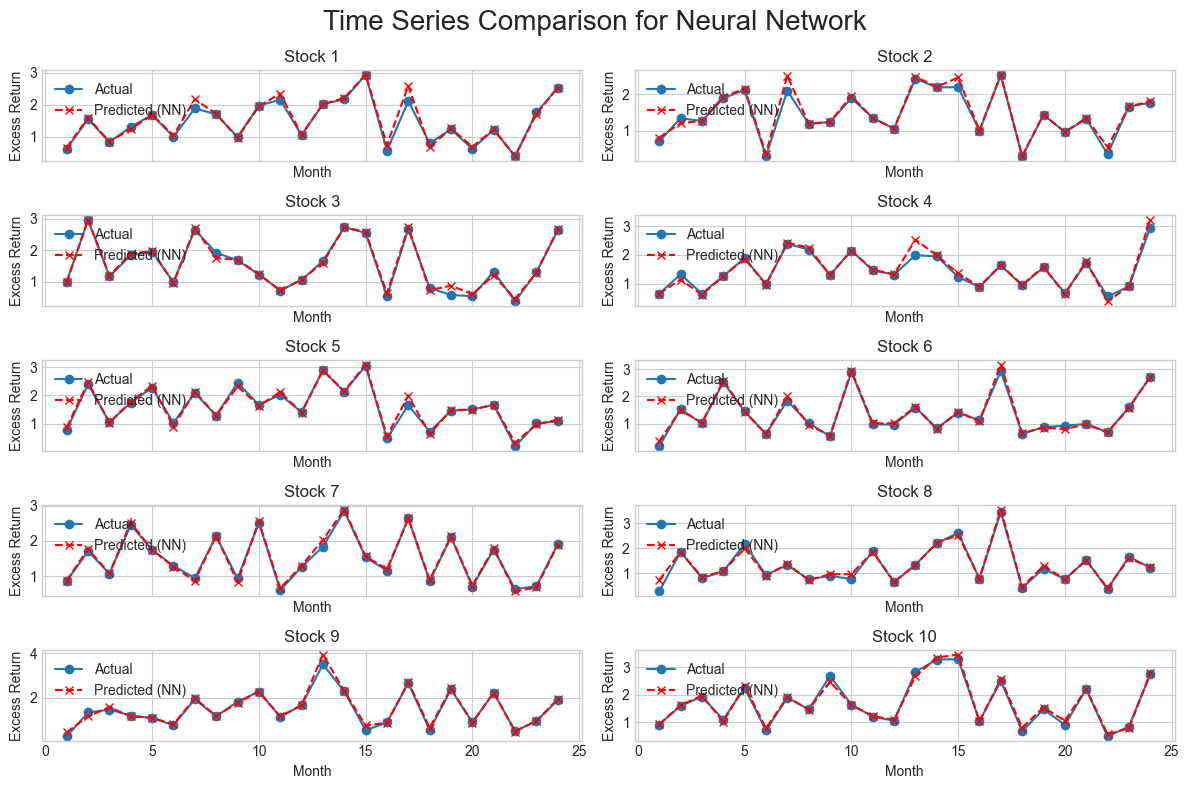

In [29]:
# compute NN predictions for all observations
X_all_nn       = scaler.transform(X_all)
y_pred_nn_all  = nn_final.predict(X_all_nn).flatten()

# plot actual vs. NN predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Neural Network", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_nn_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (NN)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [30]:
# -------------------------------
# Part 6: Out-of-Sample R² Results Table (ordered)
# -------------------------------
def oos_r2(y_true, y_pred):
    """
    Out-of-sample R²:
    1 - (sum of squared errors) / (sum of squared actuals)
    """
    return 1 - np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)

# specify desired order
order = ['OLS', 'WLS', 'Huber', 'ENet', 'PCR', 'PLS', 'GLM', 'NN', 'GBR', 'RF']

# collect test-set predictions
models_preds = {
    'OLS': y_pred_ols,
    'WLS': y_pred_wls,
    'Huber': y_pred_huber,
    'ENet': y_pred_enet,
    'PCR': y_pred_pcr,
    'PLS': y_pred_pls,
    'GLM': y_pred_glm,
    'GBR': y_pred_gbr,
    'RF': y_pred_rf,
    'NN': y_pred_nn
}

# print in specified order
for name in order:
    pred = models_preds[name]
    print(f"{name} OOS R²: {oos_r2(y_test, pred):.9f}")


OLS OOS R²: 0.999130164
WLS OOS R²: 0.999031721
Huber OOS R²: 0.999003926
ENet OOS R²: 0.996472028
PCR OOS R²: 0.999033779
PLS OOS R²: 0.999029952
GLM OOS R²: 0.998119658
NN OOS R²: 0.987078970
GBR OOS R²: 0.975435426
RF OOS R²: 0.978054187


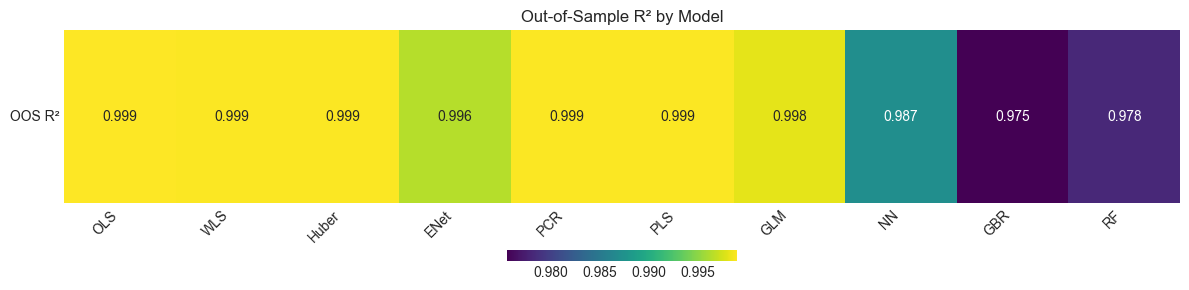

In [31]:
# build ordered R² DataFrame
r2_dict = {name: oos_r2(y_test, models_preds[name]) for name in order}
r2_df = pd.DataFrame([r2_dict], index=['OOS R²'])[order]

# plot a 1×N heatmap in the given order
plt.figure(figsize=(12, 3))
sns.heatmap(
    r2_df,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar=True,
    cbar_kws={"orientation": "horizontal", "fraction": 0.05, "pad": 0.2}
)
plt.yticks(rotation=0)          # keep the row label horizontal
plt.xticks(rotation=45, ha="right")
plt.title("Out-of-Sample R² by Model")
plt.tight_layout()
plt.show()

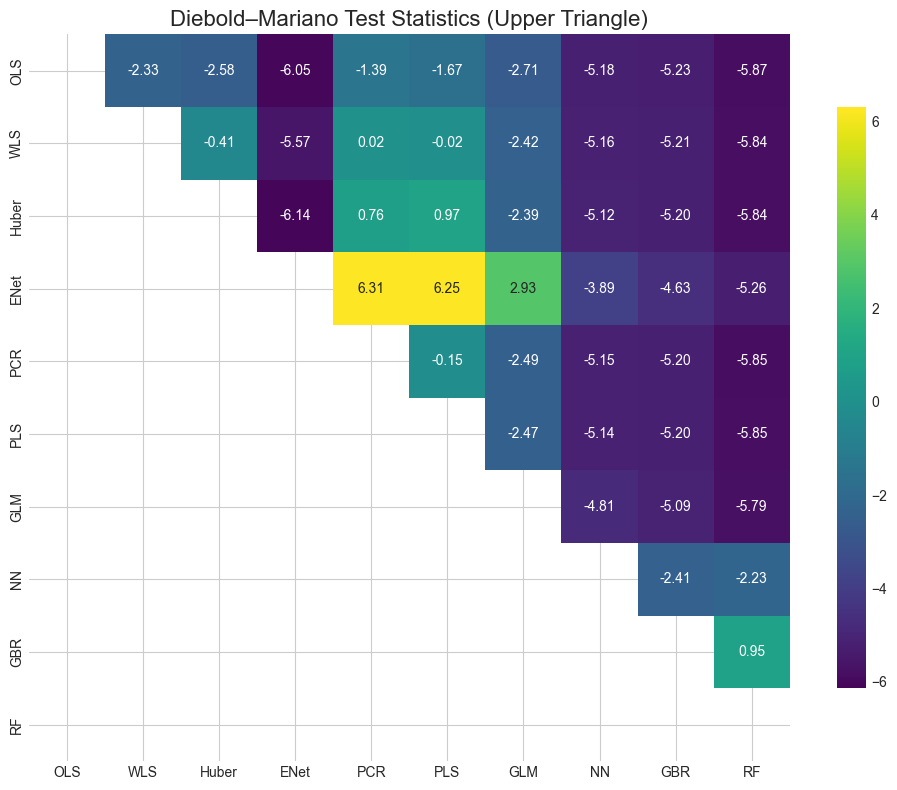

Diebold–Mariano Test Statistics:

        OLS   WLS  Huber  ENet   PCR   PLS   GLM    NN   GBR    RF
OLS     NaN -2.33  -2.58 -6.05 -1.39 -1.67 -2.71 -5.18 -5.23 -5.87
WLS    2.33   NaN  -0.41 -5.57  0.02 -0.02 -2.42 -5.16 -5.21 -5.84
Huber  2.58  0.41    NaN -6.14  0.76  0.97 -2.39 -5.12 -5.20 -5.84
ENet   6.05  5.57   6.14   NaN  6.31  6.25  2.93 -3.89 -4.63 -5.26
PCR    1.39 -0.02  -0.76 -6.31   NaN -0.15 -2.49 -5.15 -5.20 -5.85
PLS    1.67  0.02  -0.97 -6.25  0.15   NaN -2.47 -5.14 -5.20 -5.85
GLM    2.71  2.42   2.39 -2.93  2.49  2.47   NaN -4.81 -5.09 -5.79
NN     5.18  5.16   5.12  3.89  5.15  5.14  4.81   NaN -2.41 -2.23
GBR    5.23  5.21   5.20  4.63  5.20  5.20  5.09  2.41   NaN  0.95
RF     5.87  5.84   5.84  5.26  5.85  5.85  5.79  2.23 -0.95   NaN


In [32]:
# -------------------------------
# Part 7: Diebold–Mariano Test Statistics - Ordered & Heatmap
# -------------------------------

# 1) Compute squared forecast errors for each model on the test set
errors = {
    name: (y_test - models_preds[name]) ** 2
    for name in order
}

# 2) Newey–West standard error function (lag = 1)
def newey_west_se(data, lag=1):
    n  = len(data)
    mu = data.mean()
    gamma = [
        np.sum((data[:n - i] - mu) * (data[i:] - mu)) / n
        for i in range(lag + 1)
    ]
    nw_var = gamma[0] + 2 * sum(
        (1 - i / (lag + 1)) * gamma[i] for i in range(1, lag + 1)
    )
    return np.sqrt(nw_var / n)

# 3) Build and reorder the DM statistic matrix
dm_stats = pd.DataFrame(index=order, columns=order, dtype=float)

for i in order:
    for j in order:
        if i == j:
            dm_stats.loc[i, j] = np.nan
        else:
            d_t    = errors[i] - errors[j]
            mean_d = d_t.mean()
            se_d   = newey_west_se(d_t, lag=1)
            dm_stats.loc[i, j] = mean_d / se_d

# 4) Mask the lower triangle (k = -1) so only upper triangle shows
mask = np.tril(np.ones(dm_stats.shape, dtype=bool), k=-1)

# 5) Plot heatmap using viridis
plt.figure(figsize=(10, 8))
sns.heatmap(
    dm_stats.astype(float),
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    center=0,
    cbar_kws={"shrink": 0.8}
)
plt.title("Diebold–Mariano Test Statistics (Upper Triangle)", fontsize=16)
plt.tight_layout()
plt.show()

# 6) Print a neat table
print("Diebold–Mariano Test Statistics:\n")
print(dm_stats.round(2).to_string())


In [33]:
# --- Part 8: Variable Importance Calculations & Heatmaps - to understand feature importance 
from sklearn.metrics import r2_score

# 1) Define a dict of prediction functions for each model,
#    so that reduced‐dimensional or transformed models work correctly.
predict_fn = {
    'OLS':  lambda X: ols_model.predict(X),
    'WLS':  lambda X: wls.predict(X),
    'Huber':lambda X: huber_model.predict(X),
    'ENet': lambda X: enet.predict(X),
    'PCR':  lambda X: lr_pcr.predict(pca_final.transform(X)),
    'PLS':  lambda X: pls_final.predict(X).flatten(),
    'GLM':  lambda X: glm_final.predict(spline.transform(X)),
    'GBR':  lambda X: gbr_final.predict(X),
    'RF':   lambda X: rf_final.predict(X),
    'NN':   lambda X: nn_final.predict(scaler.transform(X)).flatten()
}

# list of feature names
features = [col for col in combined_data.columns if col.startswith('z_')]

# 2) Compute drop‐in R² importance for each model
var_imp = {}
for name, fn in predict_fn.items():
    # baseline R² on test set
    y_full  = fn(X_test)
    r2_full = r2_score(y_test, y_full)
    imps    = []
    # drop each feature
    for j in range(X_test.shape[1]):
        X_mod    = X_test.copy()
        X_mod[:, j] = 0
        y_mod    = fn(X_mod)
        r2_mod   = r2_score(y_test, y_mod)
        imps.append(r2_full - r2_mod)
    var_imp[name] = imps

# assemble into DataFrame (features × models)
var_imp_df = pd.DataFrame(var_imp, index=features)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


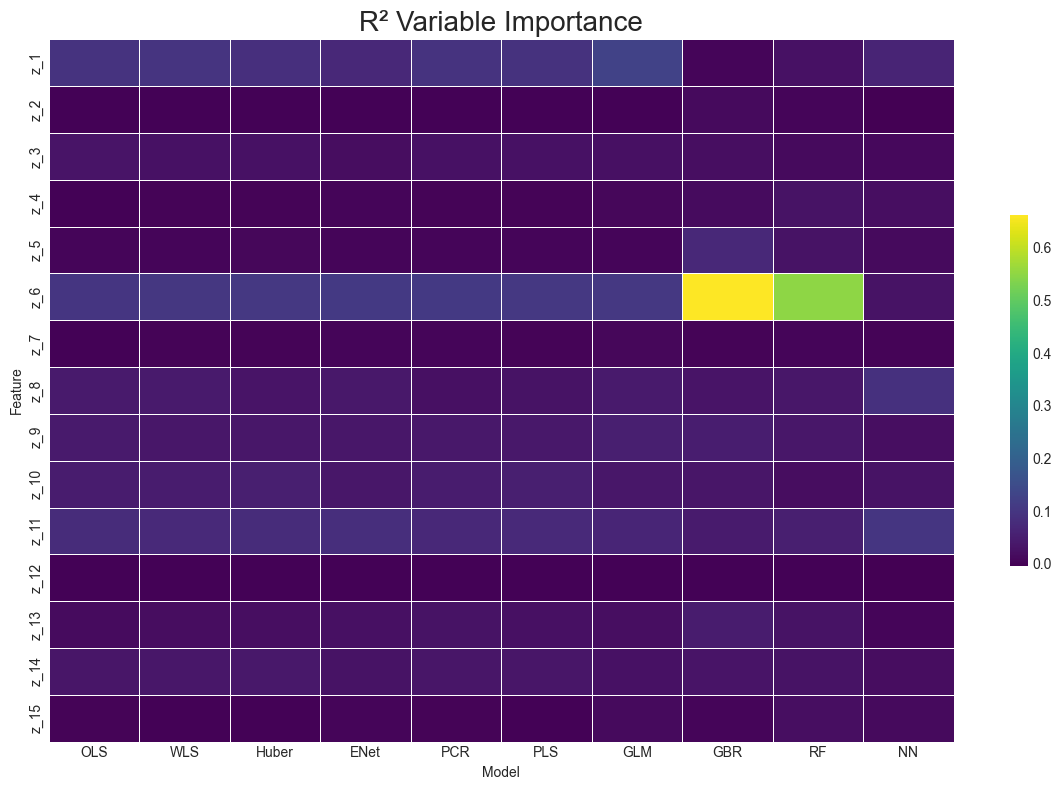

In [34]:
# 3) Heatmap of drop‐in R² importance
plt.figure(figsize=(12, 8))
sns.heatmap(
    var_imp_df,
    cmap="viridis",
    cbar_kws={"shrink":0.5},
    linewidths=0.5,
    fmt=".3f"
)
plt.title("R² Variable Importance", fontsize=20)
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [35]:
# --- SSD Importance Heatmap (Neural Network) ---

epsilon = 1e-5
ssd_vals = []

for j in range(X_tr_nn.shape[1]):
    ssd_j = 0.0
    for i in range(X_tr_nn.shape[0]):
        Xp = X_tr_nn.copy(); Xm = X_tr_nn.copy()
        Xp[i, j] += epsilon
        Xm[i, j] -= epsilon
        yp = nn_final.predict(Xp).flatten()[i]
        ym = nn_final.predict(Xm).flatten()[i]
        grad = (yp - ym) / (2 * epsilon)
        ssd_j += grad**2
    ssd_vals.append(ssd_j)

# assemble into DataFrame
ssd_df = pd.DataFrame({'Feature': features, 'SSD': ssd_vals}).set_index('Feature')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6

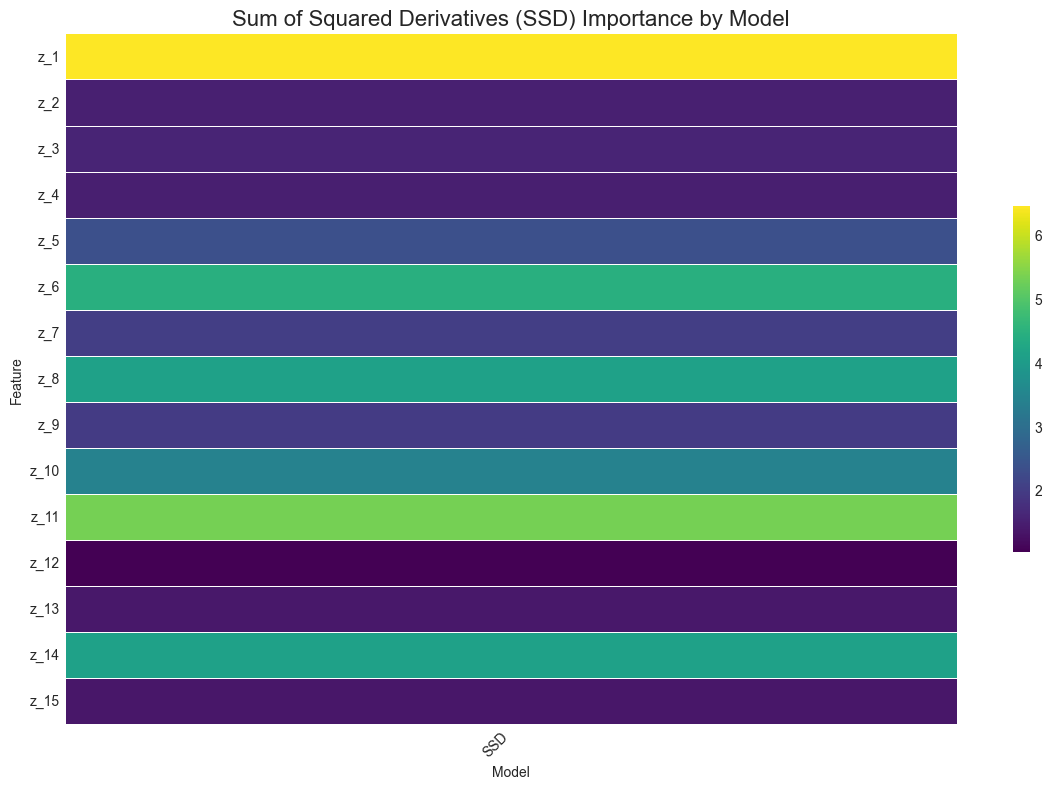

In [36]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    ssd_df,
    cmap="viridis",
    cbar_kws={"shrink": 0.5},
    linewidths=0.5,
    fmt=".0f"
)
plt.title("Sum of Squared Derivatives (SSD) Importance by Model", fontsize=16)
plt.xlabel("Model")
plt.ylabel("Feature")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [37]:
# -------------------------------
# Part 9: Auxiliary Functions and Decile Portfolio Analysis - to analyze model performance across deciles - to compare predicted vs actual  sharpe ratios
# -------------------------------

def assign_decile(x):
    if x.nunique()==1: return pd.Series(1,index=x.index)
    ranks=x.rank(method='first'); n=len(x)
    return np.ceil(ranks*10/n).astype(int)
def safe_div(a,b): return a/b if b!=0 else np.nan
# test indices
idx = train_test_split(np.arange(len(y)),test_size=0.3,random_state=42)[1]
df_test = Ri.iloc[idx].reset_index(drop=True)
results={}
for name, pred in models_preds.items():
    df = df_test.copy(); df['Pred']=pred
    df['Decile']=df.groupby('Month')['Pred'].transform(assign_decile)
    stats = df.groupby(['Month','Decile']).agg({'Pred':'mean','Excess_Return':'mean'}).reset_index()
    dec = stats.groupby('Decile').agg({'Pred':['mean','std'],'Excess_Return':['mean','std']})
    dec.columns=['MP','SDP','MA','SDA']; dec=dec.reset_index()
    dec['SR_Pred']=dec.apply(lambda r: safe_div(r['MP'],r['SDP']),axis=1)
    dec['SR_Act']=dec.apply(lambda r: safe_div(r['MA'],r['SDA']),axis=1)
    maxd, mind = 10,1
    ls_pred = dec.loc[dec.Decile==maxd,'MP'].values[0]-dec.loc[dec.Decile==mind,'MP'].values[0]
    ls_sd   = np.sqrt(dec.loc[dec.Decile==maxd,'SDP']**2 + dec.loc[dec.Decile==mind,'SDP']**2)
    ls_sr_pred = safe_div(ls_pred, ls_sd)
    results[name] = {'DecileStats':dec, 'LS_SR_Pred':ls_sr_pred}
    print(f"{name} Long-Short Pred Sharpe: {ls_sr_pred:.4f}")


NameError: name 'Ri' is not defined